<a href="https://colab.research.google.com/github/AntonDozhdikov/politpredict/blob/main/MARL_postSoviet_MEIMO.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# MARL для постсоветского пространства на реальных данных

**Назначение.** Воспроизводимый пилотный эксперимент для статьи в журнал «Мировая экономика и международные отношения» (МЭиМО).

**Среда исполнения.** Google Colab, GPU T4. Полный прогон — 30–60 минут.

**Что делает ноутбук.**
1. Устанавливает зависимости и фиксирует сиды.
2. Загружает реальные показатели World Bank WDI по 10 постсоветским странам (1995–2023) через официальный API; при недоступности сети использует встроенный кеш `data/raw/wdi_indicators.csv`.
3. Агрегирует Балтию (EST+LVA+LTU) в одного агента, формирует панель из 8 страновых агентов.
4. Обучает облегчённый MAPPO (PPO-Clip + GAE + централизованный критик) с разделяемыми параметрами актора на 3 случайных сидах.
5. Проводит сценарное моделирование 2024–2035 для трёх ветвей: S_base, S_shock, S_cooperation.
6. Сохраняет все артефакты в `results/` и собирает архив `results.zip` (графики PNG, таблицы CSV/XLSX, JSON с конфигурацией и метриками, лог пакетов).

**Воспроизводимость.** Сиды зафиксированы (`random`, `numpy`, `torch`, `cudnn.deterministic=True`). Конфигурация прогона полностью сериализована.

**Замечание о статусе результатов.** Данный ноутбук — пилотная имплементация. Финальные численные результаты статьи будут получены после запуска ноутбука пользователем с приложением загруженного архива `results.zip` к рукописи. До этого в `article_draft.md` стоят TODO-плейсхолдеры.

## 1. Установка зависимостей и подготовка окружения

In [1]:
# === ЯЧЕЙКА 1.1: установка пакетов ===
# В Colab выполняется один раз. На локальной машине большинство пакетов
# уже установлены — pip отработает быстро.
import sys
import subprocess

REQUIRED = [
    'torch>=2.0',
    'numpy>=1.24',
    'pandas>=2.0',
    'matplotlib>=3.7',
    'seaborn>=0.12',
    'tqdm>=4.65',
    'requests>=2.31',
    'openpyxl>=3.1',
    'scipy>=1.11',
]

def _pip(*args):
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', '--quiet', *args])

for pkg in REQUIRED:
    try:
        _pip(pkg)
    except Exception as exc:
        print(f'[WARN] Не удалось установить {pkg}: {exc}')

print('Зависимости установлены.')


Зависимости установлены.


In [2]:
# === ЯЧЕЙКА 1.2: импорты и проверка GPU ===
import json, os, random, time, zipfile, math, sys
from pathlib import Path
from contextlib import contextmanager
from dataclasses import dataclass, field, asdict
from typing import Dict, List, Optional, Tuple

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import requests
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch import optim
from tqdm.auto import tqdm

# Статический бэкенд matplotlib для корректного отображения на GitHub
%matplotlib inline
plt.rcParams.update({
    'figure.dpi': 110, 'savefig.dpi': 160,
    'figure.figsize': (9, 5),
    'font.size': 11, 'axes.titlesize': 13, 'axes.titleweight': 'bold',
    'axes.grid': True, 'grid.alpha': 0.3,
})
sns.set_palette(['#20808D', '#A84B2F', '#1B474D', '#BCE2E7', '#944454', '#FFC553', '#848456', '#6E522B'])

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'PyTorch: {torch.__version__}')
print(f'CUDA available: {torch.cuda.is_available()}')
if torch.cuda.is_available():
    print(f'GPU: {torch.cuda.get_device_name(0)}')
print(f'DEVICE = {DEVICE}')


PyTorch: 2.11.0+cu128
CUDA available: True
GPU: Tesla T4
DEVICE = cuda


In [3]:
# === ЯЧЕЙКА 1.3: сиды и воспроизводимость ===
SEED = 42

def set_global_seed(seed: int):
    random.seed(seed)
    np.random.seed(seed)
    os.environ['PYTHONHASHSEED'] = str(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

set_global_seed(SEED)
print(f'Сиды зафиксированы: SEED={SEED}; cudnn.deterministic=True')


Сиды зафиксированы: SEED=42; cudnn.deterministic=True


In [4]:
# === ЯЧЕЙКА 1.4: рабочие каталоги ===
WORK = Path('/content/marl_meimo') if Path('/content').exists() else Path('./marl_meimo')
WORK.mkdir(parents=True, exist_ok=True)
(WORK / 'data' / 'raw').mkdir(parents=True, exist_ok=True)
RESULTS = WORK / 'results'
RESULTS.mkdir(parents=True, exist_ok=True)
(RESULTS / 'figures').mkdir(exist_ok=True)
(RESULTS / 'tables').mkdir(exist_ok=True)
(RESULTS / 'logs').mkdir(exist_ok=True)
print(f'Рабочий каталог: {WORK.resolve()}')


Рабочий каталог: /content/marl_meimo


## 2. Загрузка данных

Источник — официальный REST API World Bank v2: <https://datahelpdesk.worldbank.org/knowledgebase/articles/889392>. Подробный каталог DOI и URL — в `data/source_catalog.json`.

Перечень загружаемых индикаторов:
- `NY.GDP.MKTP.KD.ZG` — рост ВВП, % годовых.
- `NY.GDP.PCAP.PP.KD` — ВВП на душу по ППС (constant 2017 USD).
- `FP.CPI.TOTL.ZG` — инфляция CPI, % годовых.
- `SL.UEM.TOTL.ZS` — безработица, % рабочей силы.
- `NE.TRD.GNFS.ZS` — торговая открытость (экспорт+импорт к ВВП).
- `BX.KLT.DINV.WD.GD.ZS` — нетто-FDI, % ВВП.
- `MS.MIL.XPND.GD.ZS` — военные расходы, % ВВП.
- `SP.POP.TOTL` — численность населения.

Окно: 1995–2023; обучение — 2000–2019; out-of-sample — 2020–2023.

In [5]:
# === ЯЧЕЙКА 2.1: загрузка WDI ===
COUNTRIES = ['RUS', 'UKR', 'BLR', 'KAZ', 'UZB', 'ARM', 'AZE', 'EST', 'LVA', 'LTU']
YEAR_START, YEAR_END = 1995, 2023

WDI_INDICATORS = {
    'gdp_per_capita_ppp':           'NY.GDP.PCAP.PP.KD',
    'gdp_growth':                   'NY.GDP.MKTP.KD.ZG',
    'inflation_cpi':                'FP.CPI.TOTL.ZG',
    'unemployment':                 'SL.UEM.TOTL.ZS',
    'trade_openness':               'NE.TRD.GNFS.ZS',
    'fdi_net_inflows_pct_gdp':      'BX.KLT.DINV.WD.GD.ZS',
    'military_expenditure_pct_gdp': 'MS.MIL.XPND.GD.ZS',
    'population_total':             'SP.POP.TOTL',
}

WB_API = 'https://api.worldbank.org/v2/country/{country}/indicator/{indicator}'

def _fetch(indicator_code, country, retries=3, timeout=30):
    url = WB_API.format(country=country, indicator=indicator_code)
    params = {'date': f'{YEAR_START}:{YEAR_END}', 'format': 'json', 'per_page': 200}
    for attempt in range(retries):
        try:
            r = requests.get(url, params=params, timeout=timeout,
                             headers={'User-Agent': 'MARL-MEIMO/1.0'})
            r.raise_for_status()
            data = r.json()
            if len(data) < 2 or data[1] is None:
                return []
            return [{'country': country, 'year': int(e['date']), 'value': e['value']}
                    for e in data[1]]
        except Exception as exc:
            time.sleep(2.0 ** attempt)
    print(f'[WARN] {indicator_code}/{country}: пропущено')
    return []

def download_wdi():
    frames = {}
    for short, code in tqdm(WDI_INDICATORS.items(), desc='WDI', unit='ind'):
        rows = []
        for c in COUNTRIES:
            rows.extend(_fetch(code, c))
        if rows:
            df = pd.DataFrame(rows).rename(columns={'value': short})
            frames[short] = df
    if not frames:
        return None
    out = None
    for short, df in frames.items():
        out = df if out is None else out.merge(df, on=['country','year'], how='outer')
    return out.sort_values(['country','year']).reset_index(drop=True)

wdi_cache = WORK / 'data' / 'raw' / 'wdi_indicators.csv'
wdi_df = None

# Сначала пробуем кэш (если есть в пакете)
if wdi_cache.exists():
    wdi_df = pd.read_csv(wdi_cache)
    print(f'Кэш найден: {wdi_df.shape}')

if wdi_df is None or wdi_df.empty:
    print('Кэш пуст — пробую сетевую загрузку через WB API…')
    try:
        wdi_df = download_wdi()
        if wdi_df is not None:
            wdi_df.to_csv(wdi_cache, index=False)
            print(f'Сохранено в {wdi_cache}: {wdi_df.shape}')
    except Exception as exc:
        print(f'[ERROR] Сетевая загрузка не удалась: {exc}')
        raise

assert wdi_df is not None and not wdi_df.empty, 'WDI данные не загружены'
print('\nКоличество строк по странам:')
print(wdi_df.groupby('country').size())
wdi_df.head()


Кэш найден: (290, 11)

Количество строк по странам:
country
ARM    29
AZE    29
BLR    29
EST    29
KAZ    29
LTU    29
LVA    29
RUS    29
UKR    29
UZB    29
dtype: int64


,country,year,gdp_per_capita_ppp,gdp_growth,inflation_cpi,unemployment,trade_openness,fdi_net_inflows_pct_gdp,military_expenditure_pct_gdp,population_total,gov_debt_to_gdp
0,ARM,1995,3480.755937,6.899998,175.951326,6.7,86.114857,1.724423,4.059312,3307581,NaN
1,ARM,1996,3717.335765,5.865401,18.681186,9.3,79.229560,1.100209,3.281867,3278735,NaN
2,ARM,1997,3879.179380,3.321080,13.960764,10.8,78.547745,3.168054,3.909399,3246289,NaN
3,ARM,1998,4211.512768,7.300000,8.672486,9.4,71.842452,12.270780,3.528096,3208401,NaN
4,ARM,1999,4406.967067,3.300000,0.648246,11.2,70.560479,6.612581,3.697374,3167286,NaN


Покрытие индикаторов (доля непустых ячеек):
country                         1.000000
year                            1.000000
gdp_per_capita_ppp              1.000000
gdp_growth                      1.000000
fdi_net_inflows_pct_gdp         1.000000
population_total                1.000000
unemployment                    0.993103
trade_openness                  0.993103
inflation_cpi                   0.944828
military_expenditure_pct_gdp    0.931034
gov_debt_to_gdp                 0.289655


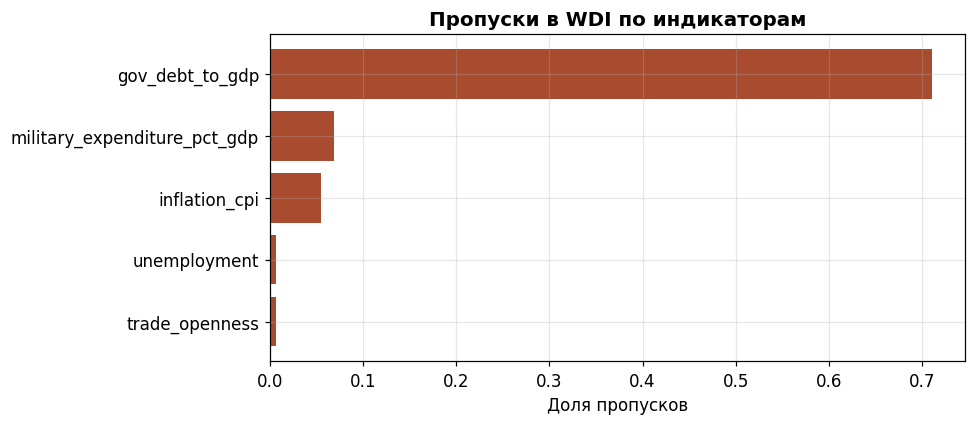

In [6]:
# === ЯЧЕЙКА 2.2: качество данных ===
coverage = wdi_df.notna().mean().sort_values(ascending=False)
print('Покрытие индикаторов (доля непустых ячеек):')
print(coverage.to_string())

fig, ax = plt.subplots(figsize=(9, 4))
miss = (1 - wdi_df.set_index(['country','year']).notna().mean(axis=0)).sort_values()
miss = miss[miss > 0]
ax.barh(miss.index, miss.values, color='#A84B2F')
ax.set_xlabel('Доля пропусков')
ax.set_title('Пропуски в WDI по индикаторам')
fig.tight_layout()
fig.savefig(RESULTS / 'figures' / 'fig01_data_coverage.png', dpi=160, bbox_inches='tight')
plt.show()


In [7]:
# === ЯЧЕЙКА 2.3: предобработка ===
BALTIC = ['EST', 'LVA', 'LTU']

def aggregate_baltic(df):
    rest = df[~df['country'].isin(BALTIC)].copy()
    bal_src = df[df['country'].isin(BALTIC)].copy()
    rows = []
    for year, sub in bal_src.groupby('year'):
        sub = sub.dropna(subset=['population_total'])
        if sub.empty:
            continue
        w = sub['population_total'] / sub['population_total'].sum()
        agg = {'country': 'BAL', 'year': year}
        for col in sub.columns:
            if col in ('country','year'):
                continue
            if col == 'population_total':
                agg[col] = sub[col].sum()
            else:
                vals = sub[col].astype(float)
                if vals.notna().any():
                    agg[col] = float((vals.fillna(vals.mean()) * w).sum())
                else:
                    agg[col] = np.nan
        rows.append(agg)
    return pd.concat([rest, pd.DataFrame(rows)], axis=0, ignore_index=True)

panel = aggregate_baltic(wdi_df)
for c in [c for c in panel.columns if c not in ('country','year')]:
    panel[c] = panel.groupby('country')[c].transform(
        lambda s: s.interpolate(method='linear', limit_direction='both'))

# log-преобразования
panel['log_gdp_pcap'] = np.log(panel['gdp_per_capita_ppp'].clip(lower=100))
panel['log_population'] = np.log(panel['population_total'].clip(lower=1))

AGENTS = ['RUS', 'UKR', 'BLR', 'KAZ', 'UZB', 'ARM', 'AZE', 'BAL']
panel = panel[panel['country'].isin(AGENTS)].copy()
panel = panel[(panel['year'] >= 2000) & (panel['year'] <= 2023)].copy()

FEATURES = ['gdp_growth', 'inflation_cpi', 'unemployment', 'trade_openness',
            'fdi_net_inflows_pct_gdp', 'military_expenditure_pct_gdp',
            'log_gdp_pcap', 'log_population']

# z-score по train (2000–2019)
train_mask = panel['year'] <= 2019
norm_stats = {}
for c in FEATURES:
    mu = float(panel.loc[train_mask, c].mean())
    sd = float(panel.loc[train_mask, c].std() + 1e-6)
    norm_stats[c] = (mu, sd)
    panel[c] = (panel[c] - mu) / sd

panel = panel.sort_values(['country','year']).reset_index(drop=True)
print('Панель готова:', panel.shape)
print('Агенты:', AGENTS)
print('Признаки:', FEATURES)
panel.head()


Панель готова: (192, 13)
Агенты: ['RUS', 'UKR', 'BLR', 'KAZ', 'UZB', 'ARM', 'AZE', 'BAL']
Признаки: ['gdp_growth', 'inflation_cpi', 'unemployment', 'trade_openness', 'fdi_net_inflows_pct_gdp', 'military_expenditure_pct_gdp', 'log_gdp_pcap', 'log_population']


,country,year,gdp_per_capita_ppp,gdp_growth,inflation_cpi,unemployment,trade_openness,fdi_net_inflows_pct_gdp,military_expenditure_pct_gdp,population_total,gov_debt_to_gdp,log_gdp_pcap,log_population
0,ARM,2000,4589.008250,0.083245,-0.724990,0.673252,-0.517019,0.032429,0.956454,3221100,50.028421,-2.037205,-1.428643
1,ARM,2001,5044.116478,0.700816,-0.477658,0.648245,-0.595958,-0.263372,0.603329,3211800,50.028421,-1.885252,-1.431167
2,ARM,2002,5731.353466,1.301695,-0.608704,0.615604,-0.458669,-0.076270,0.252848,3199800,50.028421,-1.679995,-1.434434
3,ARM,2003,6569.260234,1.435224,-0.378666,0.584280,-0.256517,-0.115153,0.277864,3182500,50.028421,-1.460725,-1.439166
4,ARM,2004,7299.400019,0.851036,-0.237955,0.559800,-0.489120,0.233004,0.288981,3164900,50.028421,-1.291365,-1.444006


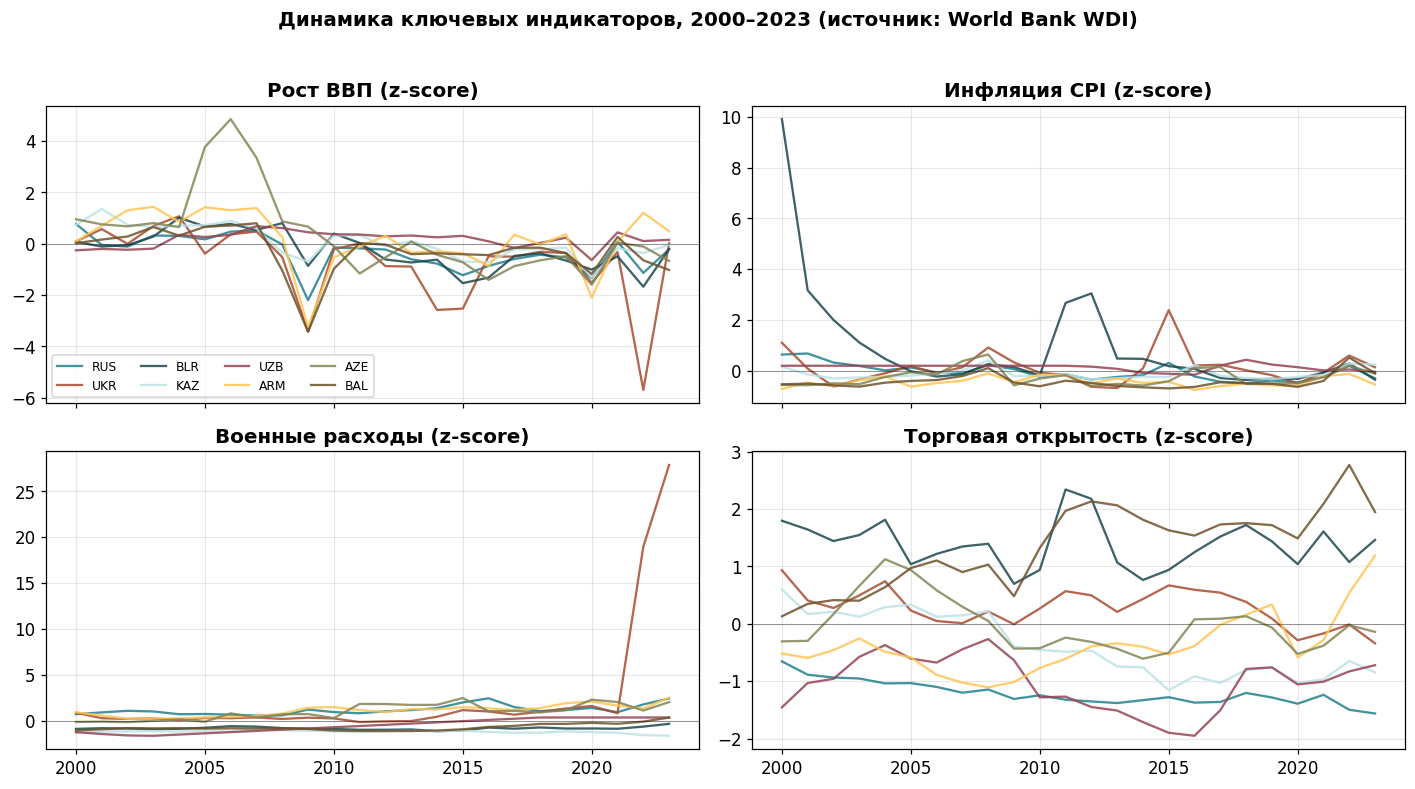

In [8]:
# === ЯЧЕЙКА 2.4: визуализация исходных рядов ===
fig, axes = plt.subplots(2, 2, figsize=(13, 7), sharex=True)
for ax, col, title in zip(
    axes.flat,
    ['gdp_growth', 'inflation_cpi', 'military_expenditure_pct_gdp', 'trade_openness'],
    ['Рост ВВП (z-score)', 'Инфляция CPI (z-score)',
     'Военные расходы (z-score)', 'Торговая открытость (z-score)']):
    for c in AGENTS:
        sub = panel[panel['country'] == c]
        ax.plot(sub['year'], sub[col], label=c, lw=1.5, alpha=0.85)
    ax.set_title(title)
    ax.axhline(0, color='black', lw=0.6, alpha=0.4)
axes[0, 0].legend(ncol=4, fontsize=8, loc='lower left')
fig.suptitle('Динамика ключевых индикаторов, 2000–2023 (источник: World Bank WDI)',
             fontsize=13, fontweight='bold', y=1.02)
fig.tight_layout()
fig.savefig(RESULTS / 'figures' / 'fig02_indicators.png', dpi=160, bbox_inches='tight')
plt.show()


## 3. Среда POSG и MAPPO

Конфигурация:

* 8 страновых агентов; локальное наблюдение = 8 признаков + 8-мерное one-hot.
* Действия (9 стратегий): `S0_status_quo`, `A1_internal_stabilization`, `A2_institutional_reform`, `C1_deepen_EAEU_CSTO`, `C2_align_EU`, `C3_align_CHN_SCO`, `D1_trade_diversification`, `D2_energy_diversification`, `K1_conflict_escalation`.
* Награда: \(r = w_g g - w_s \sigma - w_v v + w_c \kappa - w_k \chi\).
* PPO-Clip с \(\epsilon=0.2\), GAE \((\gamma, \lambda) = (0.95, 0.95)\), minibatch 256, 4 эпохи, gradient clipping 0.5.

In [9]:
# === ЯЧЕЙКА 3.1: конфигурации ===
ACTIONS = [
    'S0_status_quo', 'A1_internal_stabilization', 'A2_institutional_reform',
    'C1_deepen_EAEU_CSTO', 'C2_align_EU', 'C3_align_CHN_SCO',
    'D1_trade_diversification', 'D2_energy_diversification', 'K1_conflict_escalation',
]
N_ACTIONS = len(ACTIONS)

ACTION_EFFECTS = {
    'S0_status_quo': {},
    'A1_internal_stabilization': {'inflation_cpi': -0.05, 'unemployment': -0.04, 'gdp_growth': 0.02},
    'A2_institutional_reform': {'gdp_growth': -0.03, 'trade_openness': 0.05, 'fdi_net_inflows_pct_gdp': 0.04},
    'C1_deepen_EAEU_CSTO': {'trade_openness': 0.03, 'military_expenditure_pct_gdp': 0.03},
    'C2_align_EU': {'trade_openness': 0.05, 'fdi_net_inflows_pct_gdp': 0.05, 'military_expenditure_pct_gdp': 0.02},
    'C3_align_CHN_SCO': {'trade_openness': 0.04, 'fdi_net_inflows_pct_gdp': 0.03},
    'D1_trade_diversification': {'trade_openness': 0.02},
    'D2_energy_diversification': {'gdp_growth': -0.02, 'fdi_net_inflows_pct_gdp': 0.02},
    'K1_conflict_escalation': {'gdp_growth': -0.10, 'fdi_net_inflows_pct_gdp': -0.08, 'military_expenditure_pct_gdp': 0.15, 'inflation_cpi': 0.06},
}

@dataclass
class RewardWeights:
    w_g: float = 0.35
    w_s: float = 0.20
    w_v: float = 0.20
    w_c: float = 0.15
    w_k: float = 0.30

@dataclass
class TrainingConfig:
    n_episodes_hist: int = 600
    n_episodes_scen: int = 200
    n_seeds: int = 3
    lr_actor: float = 3e-4
    lr_critic: float = 1e-3
    gamma: float = 0.95
    gae_lambda: float = 0.95
    clip_ratio: float = 0.2
    n_epochs: int = 4
    minibatch_size: int = 256
    entropy_coef_start: float = 0.01
    entropy_coef_end: float = 0.001
    max_grad_norm: float = 0.5
    hidden_dim_actor: int = 128
    hidden_dim_critic: int = 256

REWARD = RewardWeights()
TCFG = TrainingConfig()
print('Reward weights:', REWARD)
print('Training config:', TCFG)


Reward weights: RewardWeights(w_g=0.35, w_s=0.2, w_v=0.2, w_c=0.15, w_k=0.3)
Training config: TrainingConfig(n_episodes_hist=600, n_episodes_scen=200, n_seeds=3, lr_actor=0.0003, lr_critic=0.001, gamma=0.95, gae_lambda=0.95, clip_ratio=0.2, n_epochs=4, minibatch_size=256, entropy_coef_start=0.01, entropy_coef_end=0.001, max_grad_norm=0.5, hidden_dim_actor=128, hidden_dim_critic=256)


In [10]:
# === ЯЧЕЙКА 3.2: функция награды ===
FEAT_IDX = {c: i for i, c in enumerate(FEATURES)}

def compute_rewards(state: np.ndarray, actions: np.ndarray, w: RewardWeights) -> np.ndarray:
    g = state[:, FEAT_IDX['gdp_growth']]
    inf = state[:, FEAT_IDX['inflation_cpi']]
    une = state[:, FEAT_IDX['unemployment']]
    tra = state[:, FEAT_IDX['trade_openness']]
    fdi = state[:, FEAT_IDX['fdi_net_inflows_pct_gdp']]
    mil = state[:, FEAT_IDX['military_expenditure_pct_gdp']]

    volatility = 0.5 * (inf**2) + 0.5 * (une**2)
    volatility = np.clip(volatility, 0.0, 5.0)
    vulnerability = 0.4 * inf + 0.3 * une - 0.3 * tra
    vulnerability = np.clip(vulnerability, -3.0, 5.0)
    coop = 0.5 * float(np.mean(tra)) + 0.5 * fdi
    conflict = 0.7 * mil
    for i, a in enumerate(actions):
        if ACTIONS[int(a)] == 'K1_conflict_escalation':
            conflict[i] += 1.0
    r = (w.w_g * g - w.w_s * volatility - w.w_v * vulnerability
         + w.w_c * coop - w.w_k * conflict)
    return np.tanh(r / 3.0).astype(np.float32)

_state0 = panel[panel['year'] == 2010].set_index('country').loc[AGENTS, FEATURES].values.astype(np.float32)
_acts = np.zeros(len(AGENTS), dtype=np.int64)
print('Sanity-check rewards (year=2010, all status quo):')
for c, r in zip(AGENTS, compute_rewards(_state0, _acts, REWARD)):
    print(f'  {c}: {r:+.4f}')


Sanity-check rewards (year=2010, all status quo):
  RUS: -0.1161
  UKR: -0.0438
  BLR: +0.1117
  KAZ: +0.1012
  UZB: +0.0394
  ARM: -0.4784
  AZE: -0.0440
  BAL: -0.2737


In [11]:
# === ЯЧЕЙКА 3.3: POSG-среда ===
class PostSovietEnv:
    def __init__(self, panel, features, agents, rng):
        self.panel = panel
        self.features = features
        self.agents = agents
        self.rng = rng
        self.n_agents = len(agents)
        self.obs_dim = len(features) + self.n_agents  # +ID one-hot
        self._year = None
        self._mode = None
        self._scenario = None
        self._step_idx = 0
        self._state = None

    def _build_state(self, year):
        rows = []
        for c in self.agents:
            row = self.panel[(self.panel['country'] == c) & (self.panel['year'] == year)]
            if row.empty:
                row = self.panel[self.panel['country'] == c].iloc[[-1]]
            rows.append(row[self.features].values[0].astype(np.float32))
        return np.stack(rows, axis=0)

    def _obs(self):
        eye = np.eye(self.n_agents, dtype=np.float32)
        return np.concatenate([self._state, eye], axis=1)

    def reset(self, mode='historical', scenario=None):
        self._mode = mode
        self._scenario = scenario
        self._step_idx = 0
        if mode == 'historical':
            self._year = int(self.rng.integers(2000, 2017))
        else:
            self._year = 2024
        self._state = self._build_state(min(self._year, int(self.panel['year'].max())))
        return self._obs()

    def step(self, actions):
        r = compute_rewards(self._state, actions, REWARD)
        next_year = self._year + 1
        if next_year <= int(self.panel['year'].max()) and self._mode == 'historical':
            base_next = self._build_state(next_year)
        else:
            noise = self.rng.normal(0.0, 0.05, size=self._state.shape).astype(np.float32)
            base_next = (self._state * 0.97 + noise).astype(np.float32)
        nxt = base_next.copy()
        for i, a in enumerate(actions):
            for feat, delta in ACTION_EFFECTS.get(ACTIONS[int(a)], {}).items():
                j = FEAT_IDX[feat]
                nxt[i, j] += delta
        if self._mode == 'scenario' and self._scenario is not None:
            ss = self._scenario
            nxt[:, FEAT_IDX['inflation_cpi']] += 0.5 * ss['sanctions_shock']
            nxt[:, FEAT_IDX['gdp_growth']] -= 0.3 * ss['sanctions_shock']
        self._state = nxt
        self._year = next_year
        self._step_idx += 1
        if self._mode == 'historical':
            done = self._year > 2019
        else:
            done = self._step_idx >= 12
        info = {'year': self._year - 1, 'mode': self._mode,
                'scenario': self._scenario['name'] if self._scenario else None}
        obs = self._obs() if not done else np.zeros((self.n_agents, self.obs_dim), dtype=np.float32)
        return obs, r, done, info

rng_test = np.random.default_rng(SEED)
env_test = PostSovietEnv(panel, FEATURES, AGENTS, rng_test)
obs0 = env_test.reset('historical')
print('obs shape:', obs0.shape, '(n_agents × (n_features + n_agents))')


obs shape: (8, 16) (n_agents × (n_features + n_agents))


In [12]:
# === ЯЧЕЙКА 3.4: модели (Shared Actor + Centralized Critic) ===
def _ortho(layer, gain):
    nn.init.orthogonal_(layer.weight, gain=gain)
    nn.init.zeros_(layer.bias)

class SharedActor(nn.Module):
    def __init__(self, obs_dim, n_actions, hidden=128):
        super().__init__()
        self.fc1 = nn.Linear(obs_dim, hidden); _ortho(self.fc1, math.sqrt(2))
        self.fc2 = nn.Linear(hidden, hidden); _ortho(self.fc2, math.sqrt(2))
        self.head = nn.Linear(hidden, n_actions); _ortho(self.head, 0.01)
    def forward(self, x):
        x = F.gelu(self.fc1(x)); x = F.gelu(self.fc2(x)); return self.head(x)

class CentralizedCritic(nn.Module):
    def __init__(self, obs_dim, n_agents, hidden=256):
        super().__init__()
        self.obs_dim, self.n_agents = obs_dim, n_agents
        self.fc1 = nn.Linear(obs_dim * n_agents, hidden); _ortho(self.fc1, math.sqrt(2))
        self.fc2 = nn.Linear(hidden, hidden); _ortho(self.fc2, math.sqrt(2))
        self.head = nn.Linear(hidden, 1); _ortho(self.head, 1.0)
    def forward(self, obs_all):
        if obs_all.dim() == 2:
            obs_all = obs_all.unsqueeze(0)
        B = obs_all.size(0)
        x = obs_all.view(B, self.n_agents * self.obs_dim)
        x = F.gelu(self.fc1(x)); x = F.gelu(self.fc2(x))
        return self.head(x).squeeze(-1)

_actor = SharedActor(env_test.obs_dim, N_ACTIONS).to(DEVICE)
_critic = CentralizedCritic(env_test.obs_dim, len(AGENTS)).to(DEVICE)
n_params = sum(p.numel() for p in _actor.parameters()) + sum(p.numel() for p in _critic.parameters())
print(f'Параметров (актор+критик): {n_params:,}')


Параметров (актор+критик): 118,922


In [13]:
# === ЯЧЕЙКА 3.5: PPO-обновление ===
@dataclass
class RolloutBuffer:
    obs: List = field(default_factory=list)
    actions: List = field(default_factory=list)
    log_probs: List = field(default_factory=list)
    rewards: List = field(default_factory=list)
    values: List = field(default_factory=list)

    def add(self, o, a, lp, r, v):
        self.obs.append(o); self.actions.append(a); self.log_probs.append(lp)
        self.rewards.append(r); self.values.append(v)

    def arrays(self):
        return (np.array(self.obs, dtype=np.float32),
                np.array(self.actions, dtype=np.int64),
                np.array(self.log_probs, dtype=np.float32),
                np.array(self.rewards, dtype=np.float32),
                np.array(self.values, dtype=np.float32))

def compute_gae(rewards, values, last_value, gamma, lam):
    T = rewards.shape[0]
    mean_r = rewards.mean(axis=1)
    adv = np.zeros(T, dtype=np.float32)
    gae = 0.0
    for t in reversed(range(T)):
        v_next = last_value if t == T - 1 else values[t + 1]
        delta = mean_r[t] + gamma * v_next - values[t]
        gae = delta + gamma * lam * gae
        adv[t] = gae
    ret = adv + values
    return ret.astype(np.float32), np.broadcast_to(adv[:, None], rewards.shape).copy().astype(np.float32)

class MAPPOTrainer:
    def __init__(self, obs_dim, n_agents, n_actions, cfg, device):
        self.cfg = cfg
        self.device = device
        self.actor = SharedActor(obs_dim, n_actions, cfg.hidden_dim_actor).to(device)
        self.critic = CentralizedCritic(obs_dim, n_agents, cfg.hidden_dim_critic).to(device)
        self.actor_optim = optim.Adam(self.actor.parameters(), lr=cfg.lr_actor)
        self.critic_optim = optim.Adam(self.critic.parameters(), lr=cfg.lr_critic)

    @torch.no_grad()
    def act(self, obs):
        obs_t = torch.tensor(obs, dtype=torch.float32, device=self.device)
        logits = self.actor(obs_t)
        dist = torch.distributions.Categorical(logits=logits)
        a = dist.sample()
        lp = dist.log_prob(a)
        v = self.critic(obs_t.unsqueeze(0)).item()
        return a.cpu().numpy().astype(np.int64), lp.cpu().numpy().astype(np.float32), float(v)

    def update(self, buf, last_value, progress=0.0):
        obs, acts, old_lp, r, vals = buf.arrays()
        T = obs.shape[0]
        returns, adv = compute_gae(r, vals, last_value, self.cfg.gamma, self.cfg.gae_lambda)
        adv = (adv - adv.mean()) / (adv.std() + 1e-8)

        obs_t = torch.tensor(obs, device=self.device)
        acts_t = torch.tensor(acts, device=self.device)
        old_lp_t = torch.tensor(old_lp, device=self.device)
        ret_t = torch.tensor(returns, device=self.device)
        adv_t = torch.tensor(adv, device=self.device)

        ent_coef = (self.cfg.entropy_coef_start +
                    (self.cfg.entropy_coef_end - self.cfg.entropy_coef_start) * progress)

        actor_losses, critic_losses, kls = [], [], []
        idx = np.arange(T)
        for _ in range(self.cfg.n_epochs):
            np.random.shuffle(idx)
            for st in range(0, T, max(self.cfg.minibatch_size, 1)):
                mb = idx[st:st + self.cfg.minibatch_size]
                if len(mb) == 0: continue
                mb_t = torch.as_tensor(mb, device=self.device, dtype=torch.long)
                obs_mb = obs_t.index_select(0, mb_t)
                act_mb = acts_t.index_select(0, mb_t)
                olp = old_lp_t.index_select(0, mb_t)
                ret_mb = ret_t.index_select(0, mb_t)
                adv_mb = adv_t.index_select(0, mb_t)

                B, n, d = obs_mb.shape
                logits = self.actor(obs_mb.view(B*n, d)).view(B, n, -1)
                dist = torch.distributions.Categorical(logits=logits)
                lp_new = dist.log_prob(act_mb)
                ent = dist.entropy().mean()
                ratio = torch.exp(lp_new - olp)
                s1 = ratio * adv_mb
                s2 = torch.clamp(ratio, 1.0 - self.cfg.clip_ratio,
                                 1.0 + self.cfg.clip_ratio) * adv_mb
                a_loss = -torch.min(s1, s2).mean() - ent_coef * ent
                self.actor_optim.zero_grad()
                a_loss.backward()
                nn.utils.clip_grad_norm_(self.actor.parameters(), self.cfg.max_grad_norm)
                self.actor_optim.step()

                v_pred = self.critic(obs_mb)
                c_loss = F.mse_loss(v_pred, ret_mb)
                self.critic_optim.zero_grad()
                c_loss.backward()
                nn.utils.clip_grad_norm_(self.critic.parameters(), self.cfg.max_grad_norm)
                self.critic_optim.step()

                with torch.no_grad():
                    kls.append((olp - lp_new).mean().item())
                actor_losses.append(a_loss.item())
                critic_losses.append(c_loss.item())
        return {
            'actor_loss': float(np.mean(actor_losses)),
            'critic_loss': float(np.mean(critic_losses)),
            'approx_kl': float(np.mean(kls)),
            'returns_mean': float(returns.mean()),
        }

print('MAPPO-тренер определён.')


MAPPO-тренер определён.


## 4. Обучение MAPPO

Прогон проводится на нескольких сидах (`TCFG.n_seeds`). Это даёт оценку стохастической вариативности результата и позволяет строить доверительные интервалы. Для каждого сида: 600 эпизодов на исторических данных, затем 200 эпизодов сценарного моделирования по 3 сценариям.

In [14]:
# === ЯЧЕЙКА 4.1: один прогон обучения ===
SCENARIOS = [
    {'name': 'S_base',         'sanctions_shock':  0.0},
    {'name': 'S_shock',        'sanctions_shock':  0.5},
    {'name': 'S_cooperation',  'sanctions_shock': -0.3},
]

def train_one_seed(seed: int, panel, features, agents, n_hist, n_scen):
    set_global_seed(seed)
    rng = np.random.default_rng(seed)
    env = PostSovietEnv(panel, features, agents, rng)
    trainer = MAPPOTrainer(env.obs_dim, len(agents), N_ACTIONS, TCFG, DEVICE)

    hist_rewards = []
    metrics_log = []

    # --- историческая фаза ---
    bar = tqdm(range(n_hist), desc=f'seed={seed} HIST', leave=False)
    for ep in bar:
        obs = env.reset('historical')
        buf = RolloutBuffer()
        ep_r = []
        done = False
        while not done:
            a, lp, v = trainer.act(obs)
            nxt, r, done, info = env.step(a)
            buf.add(obs, a, lp, r, v)
            ep_r.append(r.mean())
            obs = nxt
        m = trainer.update(buf, last_value=0.0, progress=ep / max(n_hist - 1, 1))
        mean_r = float(np.mean(ep_r))
        hist_rewards.append(mean_r)
        m.update({'episode': ep, 'phase': 'hist', 'mean_reward': mean_r, 'seed': seed})
        metrics_log.append(m)
        if ep % 50 == 0:
            bar.set_postfix(r=f'{mean_r:+.3f}', loss_a=f'{m["actor_loss"]:+.3f}',
                            loss_c=f'{m["critic_loss"]:.3f}')

    # --- сценарная фаза ---
    scen_records = []
    for sc in SCENARIOS:
        bar = tqdm(range(n_scen), desc=f'seed={seed} {sc["name"]}', leave=False)
        for ep in bar:
            obs = env.reset('scenario', scenario=sc)
            buf = RolloutBuffer()
            country_rewards = np.zeros(len(agents))
            country_actions = np.zeros((len(agents), N_ACTIONS), dtype=np.int64)
            T = 0
            done = False
            while not done:
                a, lp, v = trainer.act(obs)
                nxt, r, done, info = env.step(a)
                buf.add(obs, a, lp, r, v)
                country_rewards += r
                for i, ai in enumerate(a):
                    country_actions[i, int(ai)] += 1
                T += 1
                obs = nxt
            m = trainer.update(buf, last_value=0.0, progress=ep / max(n_scen - 1, 1))
            mean_r = float(country_rewards.mean() / max(T, 1))
            rec = {'seed': seed, 'scenario': sc['name'], 'episode': ep,
                   'mean_reward': mean_r, 'timesteps': T}
            for i, c in enumerate(agents):
                rec[f'reward_{c}'] = float(country_rewards[i] / max(T, 1))
                for k, an in enumerate(ACTIONS):
                    rec[f'act_{c}_{an}'] = int(country_actions[i, k])
            scen_records.append(rec)

    return {
        'seed': seed,
        'hist_rewards': hist_rewards,
        'scen_records': scen_records,
        'metrics_log': metrics_log,
    }

print('Функция train_one_seed готова.')


Функция train_one_seed готова.


In [15]:
# === ЯЧЕЙКА 4.2: основной цикл по сидам ===
timings = {}

@contextmanager
def stopwatch(label):
    t0 = time.perf_counter()
    yield
    dt = time.perf_counter() - t0
    timings[label] = dt
    print(f'[TIMER] {label}: {dt:.2f} s')

SEEDS = [SEED + i for i in range(TCFG.n_seeds)]
all_runs = {}

with stopwatch('total_training'):
    for s in SEEDS:
        with stopwatch(f'train_seed_{s}'):
            all_runs[s] = train_one_seed(
                seed=s, panel=panel, features=FEATURES, agents=AGENTS,
                n_hist=TCFG.n_episodes_hist, n_scen=TCFG.n_episodes_scen)

print('Сиды обучены:', list(all_runs.keys()))


seed=42 HIST:   0%|          | 0/600 [00:00<?, ?it/s]

seed=42 S_base:   0%|          | 0/200 [00:00<?, ?it/s]

seed=42 S_shock:   0%|          | 0/200 [00:00<?, ?it/s]

seed=42 S_cooperation:   0%|          | 0/200 [00:00<?, ?it/s]

[TIMER] train_seed_42: 125.09 s


...

seed=44 HIST:   0%|          | 0/600 [00:00<?, ?it/s]

seed=44 S_base:   0%|          | 0/200 [00:00<?, ?it/s]

seed=44 S_shock:   0%|          | 0/200 [00:00<?, ?it/s]

seed=44 S_cooperation:   0%|          | 0/200 [00:00<?, ?it/s]

[TIMER] train_seed_44: 116.95 s
[TIMER] total_training: 357.70 s
Сиды обучены: [42, 43, 44]


## 5. Анализ результатов

Графики экспортируются как статические PNG, чтобы корректно отображаться на GitHub без интерактивных виджетов.

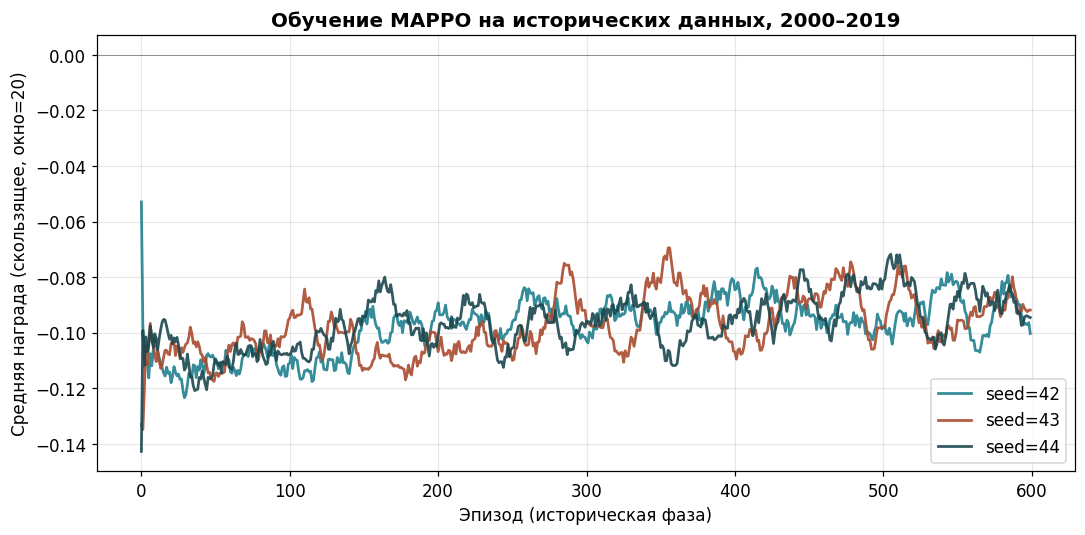

In [16]:
# === ЯЧЕЙКА 5.1: кривые обучения (исторический этап) ===
fig, ax = plt.subplots(figsize=(10, 5))
for s, run in all_runs.items():
    series = pd.Series(run['hist_rewards']).rolling(20, min_periods=1).mean()
    ax.plot(series, label=f'seed={s}', alpha=0.9, lw=1.8)
ax.set_xlabel('Эпизод (историческая фаза)')
ax.set_ylabel('Средняя награда (скользящее, окно=20)')
ax.set_title('Обучение MAPPO на исторических данных, 2000–2019')
ax.axhline(0, color='black', lw=0.6, alpha=0.4)
ax.legend()
fig.tight_layout()
fig.savefig(RESULTS / 'figures' / 'fig03_training_curves.png', dpi=160, bbox_inches='tight')
plt.show()


In [17]:
# === ЯЧЕЙКА 5.2: таблица результатов по странам и сценариям ===
scen_df = pd.concat([pd.DataFrame(r['scen_records']) for r in all_runs.values()], ignore_index=True)
print('Сценарных записей:', len(scen_df))

country_summary = (scen_df.groupby(['scenario'])[
    [f'reward_{c}' for c in AGENTS]
].agg(['mean', 'std'])).round(4)
country_summary.to_csv(RESULTS / 'tables' / 'tab01_country_scenario_summary.csv')
country_summary


Сценарных записей: 1800


reward_RUS         reward_UKR         reward_BLR          \
                    mean     std       mean     std       mean     std   
scenario                                                                 
S_base           -0.2290  0.0130    -0.9270  0.0031    -0.0009  0.0129   
S_cooperation    -0.2045  0.0166    -0.9197  0.0023     0.0156  0.0142   
S_shock          -0.3660  0.0190    -0.9510  0.0030    -0.1380  0.0145   

              reward_KAZ         reward_UZB         reward_ARM          \
                    mean     std       mean     std       mean     std   
scenario                                                                 
S_base            0.0651  0.0127    -0.0352  0.0129    -0.1072  0.0136   
S_cooperation     0.1046  0.0129     0.0027  0.0144    -0.0964  0.0154   
S_shock          -0.1108  0.0153    -0.2189  0.0175    -0.2299  0.0161   

              reward_AZE         reward_BAL          
                    mean     std       mean     std  
scenario                                             
S_base           -0.1973  0.0129    -0.0716  0.0124  
S_cooperation    -0.1659  0.0135    -0.0441  0.0125  
S_shock          -0.3476  0.0185    -0.2204  0.0136

country  mean_reward  std_reward  min_reward  max_reward
    KAZ     0.019627    0.094639   -0.157032    0.138032
    BLR    -0.041099    0.070221   -0.182209    0.058596
    UZB    -0.083798    0.097999   -0.265440    0.052790
    BAL    -0.112025    0.078544   -0.273377   -0.004643
    ARM    -0.144503    0.062418   -0.294774   -0.051921
    AZE    -0.236895    0.080752   -0.397187   -0.127408
    RUS    -0.266488    0.072932   -0.429293   -0.158406
    UKR    -0.932552    0.013655   -0.959637   -0.912522


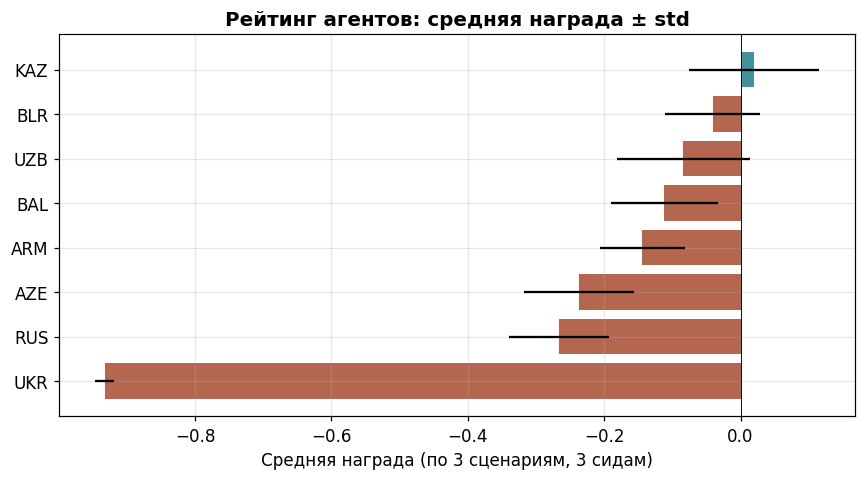

In [18]:
# === ЯЧЕЙКА 5.3: рейтинг стран по среднему вознаграждению (по всем сценариям) ===
ranking = pd.DataFrame({
    'country': AGENTS,
    'mean_reward': [scen_df[f'reward_{c}'].mean() for c in AGENTS],
    'std_reward':  [scen_df[f'reward_{c}'].std()  for c in AGENTS],
    'min_reward':  [scen_df[f'reward_{c}'].min()  for c in AGENTS],
    'max_reward':  [scen_df[f'reward_{c}'].max()  for c in AGENTS],
}).sort_values('mean_reward', ascending=False).reset_index(drop=True)
ranking.to_csv(RESULTS / 'tables' / 'tab02_country_ranking.csv', index=False)
print(ranking.to_string(index=False))

fig, ax = plt.subplots(figsize=(8, 4.5))
y = np.arange(len(ranking))
ax.barh(y, ranking['mean_reward'], xerr=ranking['std_reward'],
        color=['#20808D' if v >= 0 else '#A84B2F' for v in ranking['mean_reward']],
        alpha=0.85)
ax.set_yticks(y); ax.set_yticklabels(ranking['country'])
ax.invert_yaxis()
ax.axvline(0, color='black', lw=0.6)
ax.set_xlabel('Средняя награда (по 3 сценариям, 3 сидам)')
ax.set_title('Рейтинг агентов: средняя награда ± std')
fig.tight_layout()
fig.savefig(RESULTS / 'figures' / 'fig04_country_ranking.png', dpi=160, bbox_inches='tight')
plt.show()


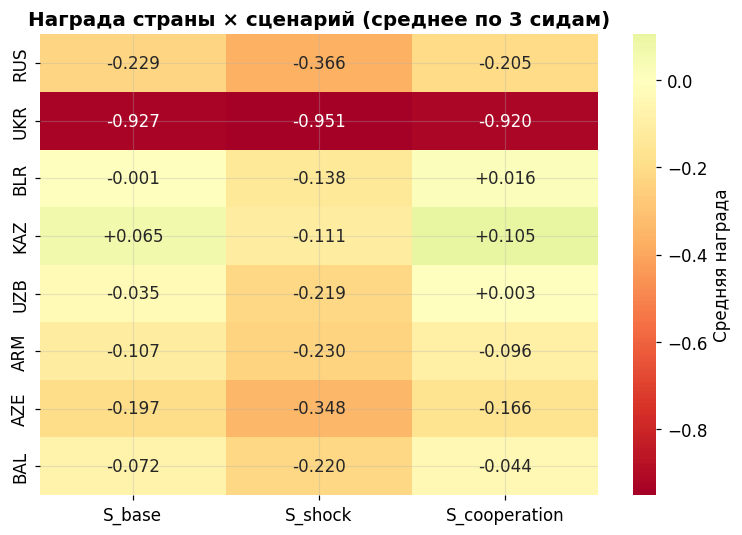

In [19]:
# === ЯЧЕЙКА 5.4: тепловая карта страна × сценарий ===
heat = pd.DataFrame(
    {sc['name']: [scen_df[scen_df.scenario == sc['name']][f'reward_{c}'].mean()
                  for c in AGENTS] for sc in SCENARIOS},
    index=AGENTS)
heat.to_csv(RESULTS / 'tables' / 'tab03_country_x_scenario.csv')

fig, ax = plt.subplots(figsize=(7, 5))
sns.heatmap(heat, annot=True, fmt='+.3f', cmap='RdYlGn', center=0,
            cbar_kws={'label': 'Средняя награда'}, ax=ax)
ax.set_title('Награда страны × сценарий (среднее по 3 сидам)')
fig.tight_layout()
fig.savefig(RESULTS / 'figures' / 'fig05_heatmap.png', dpi=160, bbox_inches='tight')
plt.show()


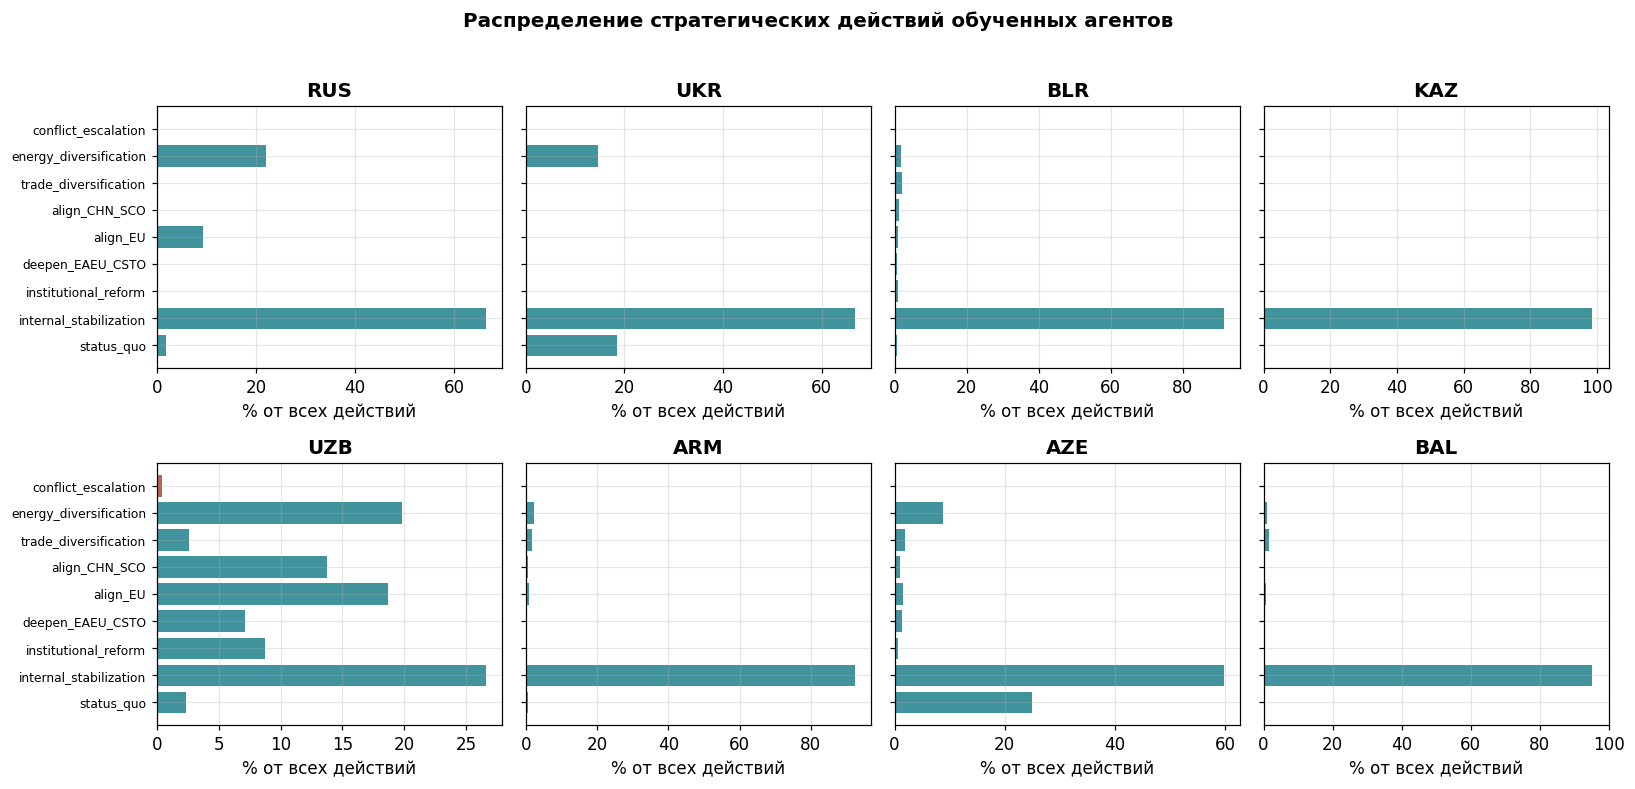

In [20]:
# === ЯЧЕЙКА 5.5: распределение действий по странам ===
act_cols = [f'act_{c}_{a}' for c in AGENTS for a in ACTIONS]
act_df = scen_df[['scenario'] + act_cols].groupby('scenario').sum()
act_df.to_csv(RESULTS / 'tables' / 'tab04_actions_by_scenario.csv')

fig, axes = plt.subplots(2, 4, figsize=(15, 7), sharey=True)
for ax, country in zip(axes.flat, AGENTS):
    cols_c = [f'act_{country}_{a}' for a in ACTIONS]
    counts = scen_df[cols_c].sum()
    pct = counts / counts.sum() * 100
    ax.barh(range(len(ACTIONS)), pct.values,
            color=['#A84B2F' if a == 'K1_conflict_escalation' else '#20808D' for a in ACTIONS],
            alpha=0.85)
    ax.set_yticks(range(len(ACTIONS)))
    ax.set_yticklabels([a.split('_', 1)[-1] for a in ACTIONS], fontsize=8)
    ax.set_title(country)
    ax.invert_yaxis()
    ax.set_xlabel('% от всех действий')
fig.suptitle('Распределение стратегических действий обученных агентов',
             fontsize=13, fontweight='bold', y=1.02)
fig.tight_layout()
fig.savefig(RESULTS / 'figures' / 'fig06_actions_distribution.png', dpi=160, bbox_inches='tight')
plt.show()


     scenario      mean      std  count
       S_base -0.187875 0.004812    600
S_cooperation -0.163462 0.005340    600
      S_shock -0.322813 0.006133    600


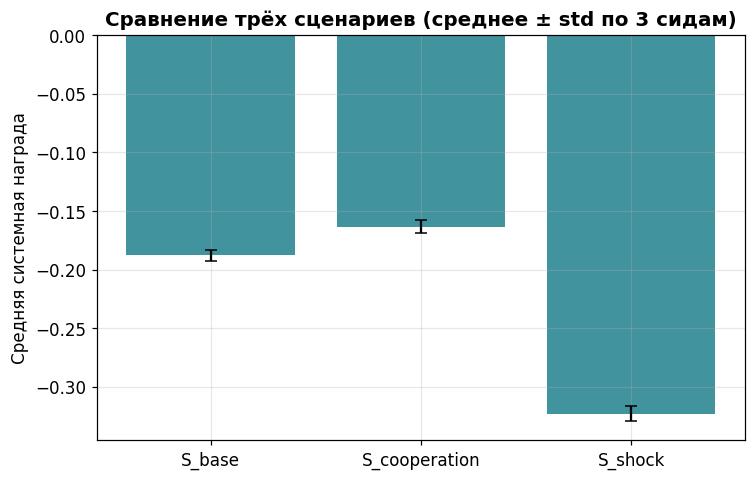

In [21]:
# === ЯЧЕЙКА 5.6: системная награда по сценариям ===
scen_overall = scen_df.groupby(['scenario'])['mean_reward'].agg(['mean','std','count']).reset_index()
scen_overall.to_csv(RESULTS / 'tables' / 'tab05_scenario_overall.csv', index=False)
print(scen_overall.to_string(index=False))

fig, ax = plt.subplots(figsize=(7, 4.5))
x = np.arange(len(scen_overall))
ax.bar(x, scen_overall['mean'], yerr=scen_overall['std'],
       color='#20808D', alpha=0.85, capsize=4)
ax.set_xticks(x); ax.set_xticklabels(scen_overall['scenario'])
ax.axhline(0, color='black', lw=0.6)
ax.set_ylabel('Средняя системная награда')
ax.set_title('Сравнение трёх сценариев (среднее ± std по 3 сидам)')
fig.tight_layout()
fig.savefig(RESULTS / 'figures' / 'fig07_scenario_overall.png', dpi=160, bbox_inches='tight')
plt.show()


## 6. Сохранение артефактов

In [22]:
# === ЯЧЕЙКА 6.1: сериализация конфига и метрик ===
config_payload = {
    'seed_base': SEED,
    'seeds_used': SEEDS,
    'countries': AGENTS,
    'features': FEATURES,
    'actions': ACTIONS,
    'action_effects': ACTION_EFFECTS,
    'reward_weights': asdict(REWARD),
    'training_config': asdict(TCFG),
    'scenarios': SCENARIOS,
    'data_window': {'train': [2000, 2019], 'test': [2020, 2023], 'scenario': [2024, 2035]},
    'device': str(DEVICE),
    'torch_version': torch.__version__,
    'cuda_available': torch.cuda.is_available(),
    'gpu_name': torch.cuda.get_device_name(0) if torch.cuda.is_available() else None,
    'timings_sec': timings,
}
with open(RESULTS / 'logs' / 'config.json', 'w', encoding='utf-8') as f:
    json.dump(config_payload, f, ensure_ascii=False, indent=2, default=str)

# Полный лог метрик обучения
metrics_all = []
for s, run in all_runs.items():
    metrics_all.extend(run['metrics_log'])
pd.DataFrame(metrics_all).to_csv(RESULTS / 'logs' / 'training_metrics.csv', index=False)

# Журнал сценарных эпизодов
scen_df.to_csv(RESULTS / 'logs' / 'scenario_episodes.csv', index=False)

# Многолистовая Excel
with pd.ExcelWriter(RESULTS / 'tables' / 'MARL_results_meimo.xlsx', engine='openpyxl') as xw:
    pd.DataFrame(metrics_all).to_excel(xw, sheet_name='train_metrics', index=False)
    scen_df.to_excel(xw, sheet_name='scenario_episodes', index=False)
    ranking.to_excel(xw, sheet_name='country_ranking', index=False)
    heat.to_excel(xw, sheet_name='country_x_scenario')
    scen_overall.to_excel(xw, sheet_name='scenario_overall', index=False)
    pd.DataFrame(SCENARIOS).to_excel(xw, sheet_name='scenarios', index=False)

# Версии пакетов
import subprocess
pkg_log = subprocess.run([sys.executable, '-m', 'pip', 'freeze'],
                         capture_output=True, text=True).stdout
(RESULTS / 'logs' / 'pip_freeze.txt').write_text(pkg_log)

print('Артефакты сохранены в', RESULTS.resolve())
for p in sorted(RESULTS.rglob('*')):
    if p.is_file():
        print(' ', p.relative_to(RESULTS), f'({p.stat().st_size/1024:.1f} KB)')


Артефакты сохранены в /content/marl_meimo/results
  figures/fig01_data_coverage.png (41.9 KB)
  figures/fig02_indicators.png (356.0 KB)
  figures/fig03_training_curves.png (184.0 KB)
  figures/fig04_country_ranking.png (37.2 KB)
  figures/fig05_heatmap.png (87.4 KB)
  figures/fig06_actions_distribution.png (115.0 KB)
  figures/fig07_scenario_overall.png (42.1 KB)
  logs/config.json (2.8 KB)
  logs/pip_freeze.txt (14.4 KB)
  logs/scenario_episodes.csv (627.0 KB)
  logs/training_metrics.csv (209.8 KB)
  tables/MARL_results_meimo.xlsx (774.5 KB)
  tables/tab01_country_scenario_summary.csv (0.6 KB)
  tables/tab02_country_ranking.csv (0.7 KB)
  tables/tab03_country_x_scenario.csv (0.5 KB)
  tables/tab04_actions_by_scenario.csv (2.7 KB)
  tables/tab05_scenario_overall.csv (0.2 KB)


In [23]:
# === ЯЧЕЙКА 6.2: формирование results.zip ===
zip_path = WORK / 'results.zip'
with zipfile.ZipFile(zip_path, 'w', zipfile.ZIP_DEFLATED) as zf:
    for p in RESULTS.rglob('*'):
        if p.is_file():
            zf.write(p, p.relative_to(WORK))

print(f'Архив: {zip_path}  ({zip_path.stat().st_size/1024:.1f} KB)')
print()
print('В Colab архив можно скачать так:')
print('    from google.colab import files; files.download("' + str(zip_path) + '")')


Архив: /content/marl_meimo/results.zip  (1696.3 KB)

В Colab архив можно скачать так:
    from google.colab import files; files.download("/content/marl_meimo/results.zip")


## 7. Что дальше

После завершения прогона:

1. **Скачайте `results.zip`**